<a href="https://colab.research.google.com/github/Dathu-03184/DL_Lab-Programs/blob/main/17%20program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 194ms/step - accuracy: 0.7343 - loss: 0.4873 - val_accuracy: 1.0000 - val_loss: 0.0119
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 195ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 6.4538e-05
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - accuracy: 1.0000 - loss: 4.5461e-05 - val_accuracy: 1.0000 - val_loss: 2.6142e-05
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 1.0000 - loss: 2.0104e-05 - val_accuracy: 1.0000 - val_loss: 1.9085e-05
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 1.0000 - loss: 1.7579e-05 - val_accuracy: 1.0000 - val_loss: 1.5942e-05
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 1.0000 - loss: 1.5318e-05 - val_accuracy: 1.0000 - val_loss: 1.4084e-05
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 1.0000 - loss: 1.3241e-05 - val_accuracy: 1.0000 - val_loss: 1.2788e-05
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - accuracy: 1

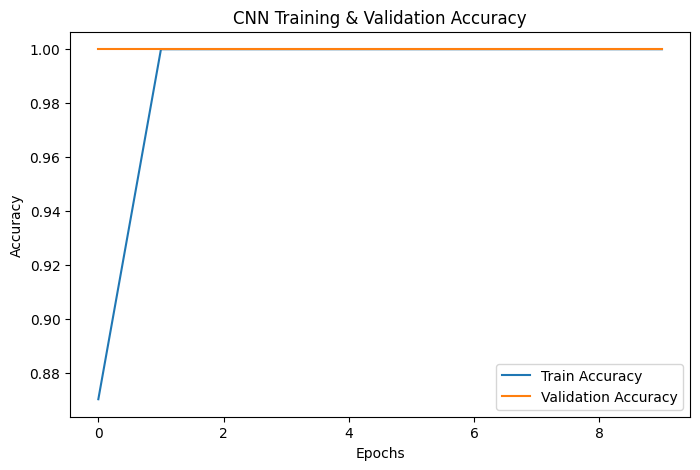

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

# 1️⃣ Generate synthetic binary image dataset (64x64 grayscale)
num_samples = 1000
img_height, img_width = 64, 64

# Class 0: random noise
X0 = np.random.rand(num_samples//2, img_height, img_width, 1)
y0 = np.zeros(num_samples//2)

# Class 1: random noise with central square pattern
X1 = np.random.rand(num_samples//2, img_height, img_width, 1)
X1[:, 16:48, 16:48, 0] += 0.5  # Add pattern
y1 = np.ones(num_samples//2)

# Combine dataset
X = np.concatenate([X0, X1], axis=0)
y = np.concatenate([y0, y1], axis=0)

# Normalize images
X = X / np.max(X)

# Convert labels to categorical (Softmax)
y_cat = to_categorical(y, num_classes=2)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=42)

# 2️⃣ Build CNN model
model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(img_height, img_width,1)),
    MaxPooling2D((2,2)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(2, activation='softmax')  # Softmax for binary classification
])

# 3️⃣ Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4️⃣ Train model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# 5️⃣ Evaluate model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {accuracy:.3f}")

# 6️⃣ Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

# 7️⃣ Classification report & confusion matrix
print("\nClassification Report:")
print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# 8️⃣ Plot training history
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Training & Validation Accuracy')
plt.legend()
plt.show()
